In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from module import Architecture

from module.Trainner import Trainner, Inference
from module.DataLoader import DataLoader

In [2]:
data = DataLoader(path="./data/ANN", type="EMNIST", batch=64)
ANN_architecture = Architecture.ANN(input=28*28, hidden_size=[1024, 512, 256], output=47)

train, test = data.Loader()
test_data, test_labels = data.extract(test)

In [3]:
ANNTrain = Trainner(ANN_architecture, "adam", 1e-3, nn.CrossEntropyLoss())
ANNTrain.fit(train, epochs=10, verbose=True, val_data=test)

Epoch 1/10 - Loss: 0.9802 - Acc: 70.1312 - Val Loss: 0.5840 - Val Acc: 80.6436
Epoch 2/10 - Loss: 0.6630 - Acc: 77.9982 - Val Loss: 0.5000 - Val Acc: 83.2234
Epoch 3/10 - Loss: 0.5876 - Acc: 80.1011 - Val Loss: 0.4638 - Val Acc: 84.1117
Epoch 4/10 - Loss: 0.5418 - Acc: 81.4965 - Val Loss: 0.4372 - Val Acc: 85.1543
Epoch 5/10 - Loss: 0.5102 - Acc: 82.2890 - Val Loss: 0.4319 - Val Acc: 85.0000
Epoch 6/10 - Loss: 0.4828 - Acc: 83.2243 - Val Loss: 0.4202 - Val Acc: 85.5319
Epoch 7/10 - Loss: 0.4651 - Acc: 83.5993 - Val Loss: 0.4094 - Val Acc: 86.0053
Epoch 8/10 - Loss: 0.4477 - Acc: 84.1684 - Val Loss: 0.4000 - Val Acc: 86.0266
Epoch 9/10 - Loss: 0.4343 - Acc: 84.4947 - Val Loss: 0.3969 - Val Acc: 86.1011
Epoch 10/10 - Loss: 0.4214 - Acc: 84.8254 - Val Loss: 0.3889 - Val Acc: 86.5904


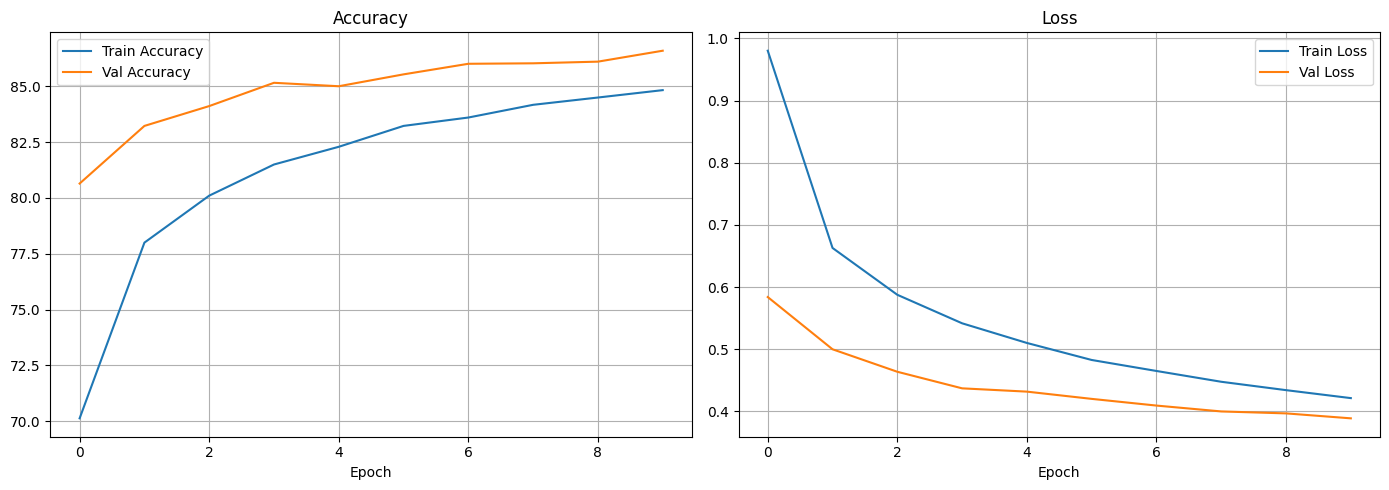

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(ANNTrain.accuracy_history, label='Train Accuracy')
ax1.plot(ANNTrain.val_accuracy_history, label='Val Accuracy')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

# Loss
ax2.plot(ANNTrain.loss_history, label='Train Loss')
ax2.plot(ANNTrain.val_loss_history, label='Val Loss')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

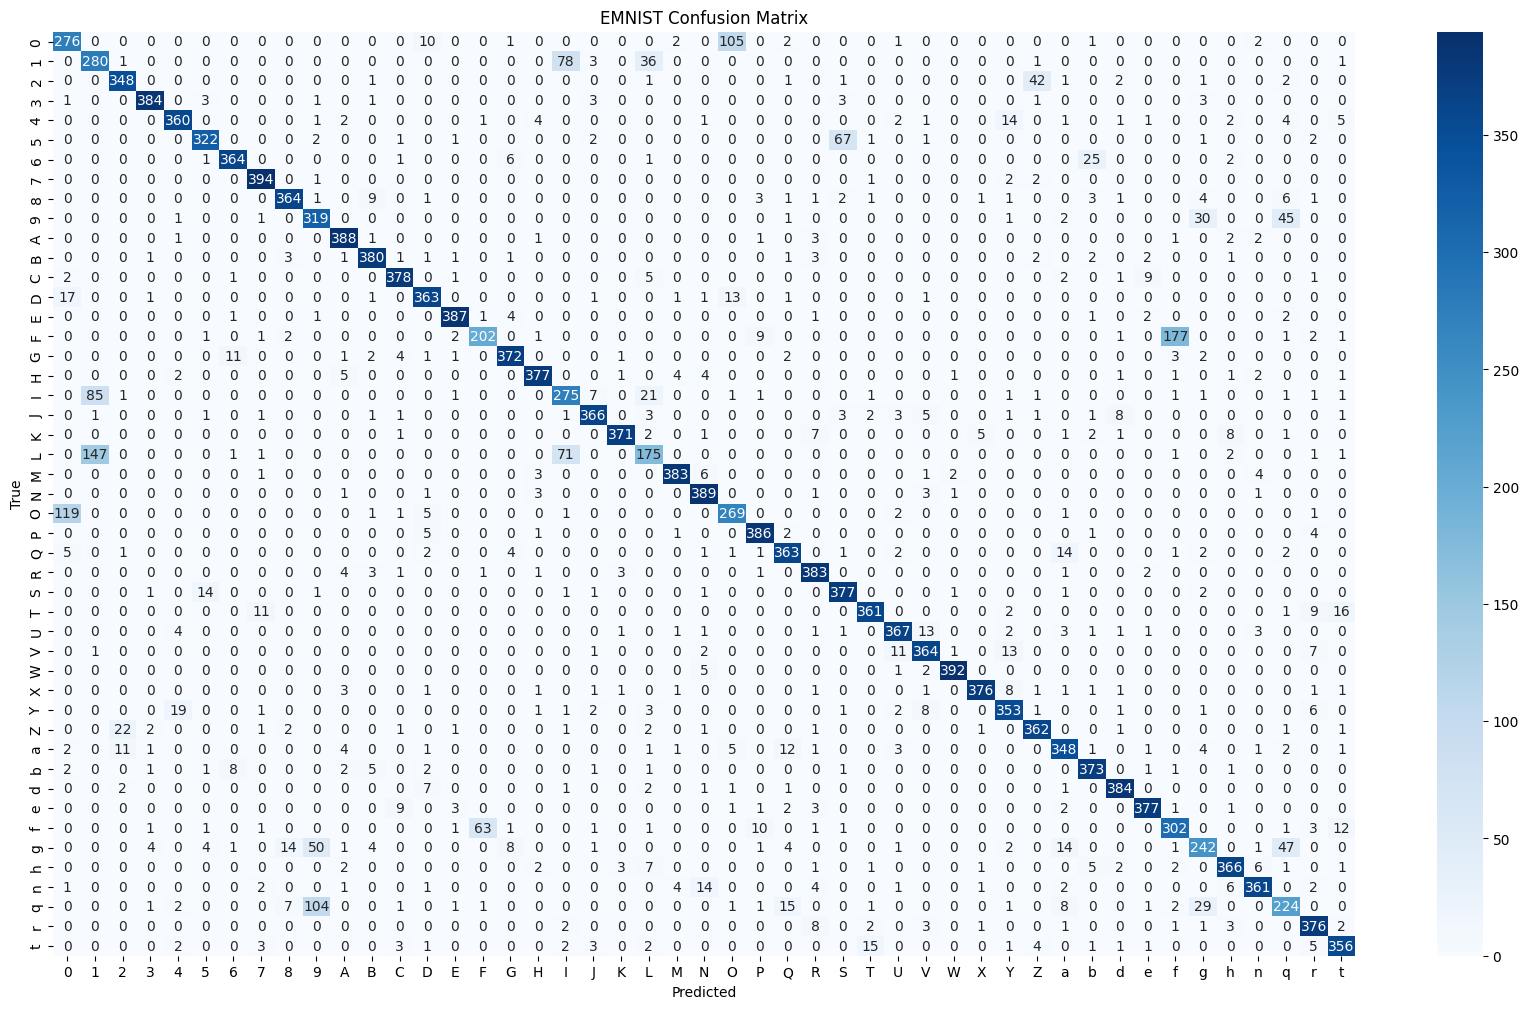

In [5]:
test_accuracy, prediction, true_labels, x_test = ANNTrain.evaluate(test)

emnist_labels = (
    [str(i) for i in range(10)] +          # 0-9
    [chr(i) for i in range(65, 91)] +      # A-Z
    list('abdefghnqrt')                    # 36-46 
)

cm = confusion_matrix(true_labels, prediction)

plt.figure(figsize=(21, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emnist_labels,
    yticklabels=emnist_labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EMNIST Confusion Matrix")
plt.show()

In [6]:
def save(arch_type, model, optimizer, path):
    torch.save({
        "arch": arch_type,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }, path)
    print(f"Model saved to {path}")
    
save("ANN", ANNTrain.model, ANNTrain.optimizer, "./data/Artifact/ANN_EMNST_Balanced.pth")

Model saved to ./data/Artifact/ANN_EMNST_Balanced.pth


In [7]:
# ANN_architecture = Architecture.ANN(input=28*28, hidden_size=[1024, 512, 256], output=47)

# checkpoint = torch.load("./data/Artifact/ANN_EMNST_Balanced.pth")
# ANN_architecture.load_state_dict(checkpoint['model_state'])  # extract model_state-nya
# ANN_architecture.eval()

In [8]:
# ANN_test = Inference(ANN_architecture)
# ANN_test.load("./data/Artifact/ANN_EMNST_Balanced.pth")

In [9]:
# X_new, _ = next(iter(test))
# pred = ANN_test.predict(X_new)

# emnist_labels = (
#     [str(i) for i in range(10)] +
#     [chr(i) for i in range(65, 91)] +
#     list('abdefghnqrt')
# )
# print([emnist_labels[p] for p in pred])

# CNN

In [10]:
CNN_Architecture = Architecture.CNN()
CNNTrain = Trainner(CNN_Architecture, "adam", 1e-3, nn.CrossEntropyLoss(), False)
CNNTrain.fit(train, epochs=10, verbose=True, val_data=test)

Epoch 1/10 - Loss: 0.9663 - Acc: 69.8431 - Val Loss: 0.4601 - Val Acc: 83.9894
Epoch 2/10 - Loss: 0.5793 - Acc: 80.7642 - Val Loss: 0.4181 - Val Acc: 85.6330
Epoch 3/10 - Loss: 0.5086 - Acc: 83.0115 - Val Loss: 0.3816 - Val Acc: 86.4096
Epoch 4/10 - Loss: 0.4702 - Acc: 83.9255 - Val Loss: 0.3730 - Val Acc: 86.7447
Epoch 5/10 - Loss: 0.4368 - Acc: 84.8218 - Val Loss: 0.3563 - Val Acc: 87.4255
Epoch 6/10 - Loss: 0.4145 - Acc: 85.5532 - Val Loss: 0.3498 - Val Acc: 87.5585
Epoch 7/10 - Loss: 0.3919 - Acc: 86.1206 - Val Loss: 0.3523 - Val Acc: 87.3617
Epoch 8/10 - Loss: 0.3762 - Acc: 86.7394 - Val Loss: 0.3426 - Val Acc: 87.8457
Epoch 9/10 - Loss: 0.3641 - Acc: 87.0142 - Val Loss: 0.3377 - Val Acc: 88.1809
Epoch 10/10 - Loss: 0.3540 - Acc: 87.2970 - Val Loss: 0.3389 - Val Acc: 88.0266


In [11]:
save("CNN", CNNTrain.model, CNNTrain.optimizer, "./data/Artifact/CNN_EMNST_Balanced.pth")

Model saved to ./data/Artifact/CNN_EMNST_Balanced.pth


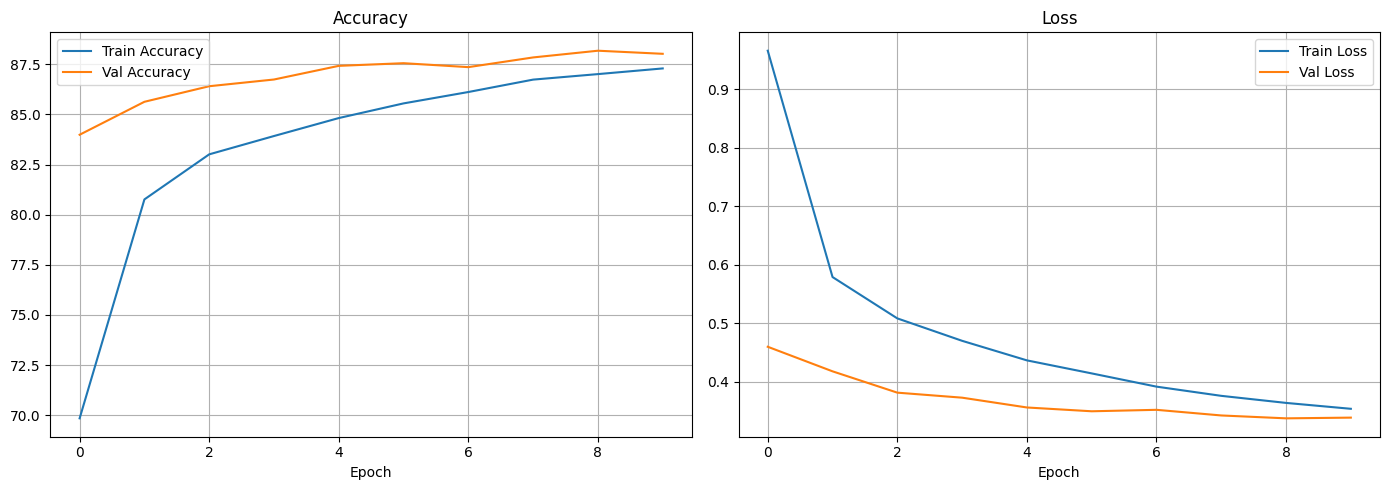

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(CNNTrain.accuracy_history, label='Train Accuracy')
ax1.plot(CNNTrain.val_accuracy_history, label='Val Accuracy')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

# Loss
ax2.plot(CNNTrain.loss_history, label='Train Loss')
ax2.plot(CNNTrain.val_loss_history, label='Val Loss')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()